<a href="https://colab.research.google.com/github/mpdivyaprabakaran-bit/us-cancer-data-analysis-project/blob/main/US_Cancer_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **US Cancer Data Analytics**


---





# **Problem Statment:**

Healthcare infrastructure and oncology resource distribution in the US face severe mismatches relative to actual patient loads, leading to delayed diagnoses and high hospital overhead. This project analyzes the 2018-2022 CDC WONDER datasets to build an operational risk-profile framework. By cross-examining population densities against localized cancer crude rates, we identify underserved geographic territories. This allows healthcare networks to optimize diagnostic equipment supply chains, strategically deploy mobile screening units, and minimize regional disparities in preventative care.

#**Objective:**
The objective of this project is to build an end-to-end data analytics pipeline using Python and Power BI to analyze the intersection of geographic, temporal, and sociodemographic drivers behind US Cancer Incidence

# **Expected Outcome:**

1. Automated Programmatic ETL Pipeline
2. Multi-Dimensional Descriptive Analytics
3. Socioeconomic & Demographic Diagnostics
4. Cohort-Based Predictive Models
5. Precision Prescriptive Recommendations
6. Advanced Interactive Dashboard

# **# Domain:** Healthcare

#**Dataset Information:**

**Source:** CDC WONDER Open Data Portal: - https://wonder.cdc.gov/cancer-v2022.html

**Year / Timeline:** Data collected during 2018 to 2022

**Dataset Features Description:**

**States**	- The geographical region of diagnosis, representing 50 US States along with the District of Columbia.

**States Code**	 - Standard numeric identifiers assigned to each specific US state.

**Year**	- The specific calendar year in which the cancer incidences were officially recorded.

**Year Code** - 	Standardized numeric classification value mapping directly to the recording year.

**Leading Cancer Sites**	- Primary anatomical location of the diagnosed invasive cancer (e.g., Breast, Lung and Bronchus, Prostate).

**Leading Cancer Sites Code**	The SEER (Surveillance, Epidemiology, and End Results) standard system alphanumeric identifier code for classification of primary tumor sites.

**Count** -	Number of newly diagnosed cancer cases documented for that state, year, and cancer site.

**Population** -	The estimated total resident population for that specific state and year.

**Age Group** -	Stratified chronological age bracket of the patients at the time of diagnosis.

**Race** - Racial demographic classification of the patient population.

**Crude Rate** -	The unadjusted baseline incidence rate per 100,000 individuals, calculated purely as: (Count/Population)×100,000.

**Crude Rate Lower 95% Confidence Interval** -	The lower mathematical boundary proving reliability and statistical stability for the raw crude metric.

**Crude Rate Upper 95% Confidence Interval** - The upper mathematical boundary proving reliability and statistical stability for the raw crude metric.

**Crude Rate Standard Error**	- The calculated standard deviation of the crude rate sampling distribution, measuring raw data precision.

# **Inital EDA**

In [ ]:
import pandas as pd
import numpy as np
from urllib.parse import quote

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import skew, kurtosis

github_url = 'https://raw.githubusercontent.com/mpdivyaprabakaran-bit/us-cancer-data-analysis-project/main/doc/raw/'
csv_files = [
    'United States and Puerto Rico Cancer Statistics - 2018 - 1.csv',
    'United States and Puerto Rico Cancer Statistics - 2018.csv',
    'United States and Puerto Rico Cancer Statistics - 2019 - 1.csv',
    'United States and Puerto Rico Cancer Statistics - 2019.csv',
    'United States and Puerto Rico Cancer Statistics - 2020 - 1.csv',
    'United States and Puerto Rico Cancer Statistics - 2020.csv',
    'United States and Puerto Rico Cancer Statistics - 2021 -1.csv',
    'United States and Puerto Rico Cancer Statistics - 2021.csv',
    'United States and Puerto Rico Cancer Statistics - 2022 -1.csv',
    'United States and Puerto Rico Cancer Statistics - 2022.csv'
]
url_list = [github_url + quote(filename) for filename in csv_files]
df_ori = pd.concat([pd.read_csv(url) for url in url_list], ignore_index=True)

In [ ]:
print('Combined Dataset: \n', df_ori.shape)
print('Head: \n', df_ori.head())
print('\nTail: \n', df_ori.tail())
print('\nColumn: \n', df_ori.columns.tolist())
print('\nData Type: \n', df_ori.dtypes)

Combined Dataset: 
 (40048, 17)
Head: 
   Notes   States  States Code    Year  Year Code Leading Cancer Sites  \
0   NaN  Alabama          1.0  2018.0     2018.0               Breast   
1   NaN  Alabama          1.0  2018.0     2018.0               Breast   
2   NaN  Alabama          1.0  2018.0     2018.0               Breast   
3   NaN  Alabama          1.0  2018.0     2018.0               Breast   
4   NaN  Alabama          1.0  2018.0     2018.0               Breast   

  Leading Cancer Sites Code   Age Groups Age Groups Code  \
0                   26000.0  30-34 years           30-34   
1                   26000.0  35-39 years           35-39   
2                   26000.0  35-39 years           35-39   
3                   26000.0  40-44 years           40-44   
4                   26000.0  40-44 years           40-44   

                        Race Race Code  Count Population Crude Rate  \
0                      White    2106-3   27.0     208556       12.9   
1  Black or Africa

In [ ]:
df_ori.isna().sum()

,0
Notes,39488
States,560
States Code,560
Year,560
Year Code,560
Leading Cancer Sites,560
Leading Cancer Sites Code,560
Age Groups,560
Age Groups Code,560
Race,560


In [ ]:
df = df_ori[df_ori['Notes'].isnull()].copy()
df.drop(columns=['Notes'], inplace=True)
df.columns = df.columns.str.strip()
print("--- Data Check ---")
print("\nRemaining Missing Values per Column:")
print(df.isnull().sum())
print(f"\n Total rows after removing footnotes: {df.shape[0]}")
print(df.shape)

--- Data Check ---

Remaining Missing Values per Column:
States                                      0
States Code                                 0
Year                                        0
Year Code                                   0
Leading Cancer Sites                        0
Leading Cancer Sites Code                   0
Age Groups                                  0
Age Groups Code                             0
Race                                        0
Race Code                                   0
Count                                       0
Population                                  0
Crude Rate                                  0
Crude Rate Lower 95% Confidence Interval    0
Crude Rate Upper 95% Confidence Interval    0
Crude Rate Standard Error                   0
dtype: int64

 Total rows after removing footnotes: 39488
(39488, 16)


In [ ]:
df.drop_duplicates(inplace=True)
print(df.shape)

(39488, 16)


# **Data Cleaning and Pre-Processing**

In [ ]:
df.replace(['Unreliable', 'Not Applicable', ' ', 'Supressed'], np.nan, inplace=True)

In [ ]:
num_cols = ['Count', 'Population', 'Crude Rate', 'Crude Rate Standard Error']
for col in num_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  df[col] = df[col].astype(str).str.strip().str.upper()

In [ ]:
df.dropna(inplace=True)
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 38225 entries, 0 to 39994
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   States                                    38225 non-null  object 
 1   States Code                               38225 non-null  float64
 2   Year                                      38225 non-null  float64
 3   Year Code                                 38225 non-null  float64
 4   Leading Cancer Sites                      38225 non-null  object 
 5   Leading Cancer Sites Code                 38225 non-null  object 
 6   Age Groups                                38225 non-null  object 
 7   Age Groups Code                           38225 non-null  object 
 8   Race                                      38225 non-null  object 
 9   Race Code                                 38225 non-null  object 
 10  Count                                  

In [ ]:
min_rate = df['Crude Rate'].min()
max_rate = df['Crude Rate'].max()
print(f'Crude Rate Range: Min = {min_rate}, Max = {max_rate}')

Crude Rate Range: Min = 0.8, Max = 2812.0


In [ ]:
q25 = df['Crude Rate'].quantile(.25)
q50 = df['Crude Rate'].quantile(.50)
q75 = df['Crude Rate'].quantile(.75)

print('--- Calculated Distribution Thresholds ---')
print(f'Low Tier spans:       0.8 to {q25:.1f}')
print(f'Medium Tier spans:    {q25:.1f} to {q50:.1f}')
print(f'High Tier spans:      {q50:.1f} to {q75:.1f}')
print(f'Critical Tier spans:  {q75:.1f} to {max_rate:.1f}')

--- Calculated Distribution Thresholds ---
Low Tier spans:       0.8 to 21.4
Medium Tier spans:    21.4 to 57.6
High Tier spans:      57.6 to 166.3
Critical Tier spans:  166.3 to 2812.0


In [ ]:
dynamic_bins = [-0.1, q25, q50, q75, np.inf]
severity_labels = ['Low', 'Medium', 'High', 'Critical']
df['Incidence_Severity'] = pd.cut(df['Crude Rate'], bins=dynamic_bins, labels=severity_labels)
df['Incidence_Severity'] = pd.Categorical(df['Incidence_Severity'], categories=severity_labels, ordered=True)

In [ ]:
df['Severity Numeric'] = df['Incidence_Severity'].cat.codes

In [ ]:
print(df['Incidence_Severity'].value_counts())

Incidence_Severity
Low         9614
Critical    9554
High        9540
Medium      9517
Name: count, dtype: int64


In [ ]:
print('Validation Check')
check_df = df[['Incidence_Severity', 'Severity Numeric']].drop_duplicates().sort_values('Severity Numeric')
print(check_df)

Validation Check
   Incidence_Severity  Severity Numeric
0                 Low                 0
1              Medium                 1
3                High                 2
11           Critical                 3


In [ ]:
race_dummies = pd.get_dummies(df['Race'], prefix='race', drop_first=False)
race_dummies = race_dummies.astype(int)
df = pd.concat([df, race_dummies], axis=1)
print('Newly generated diagnostic columns: ')
print(race_dummies.columns.tolist())

Newly generated diagnostic columns: 
['race_AMERICAN INDIAN OR ALASKA NATIVE', 'race_ASIAN OR PACIFIC ISLANDER', 'race_BLACK OR AFRICAN AMERICAN', 'race_WHITE']


In [ ]:
df.shape

(38225, 22)

In [ ]:
df.describe()

,States Code,Year,Year Code,Count,Population,Crude Rate,Crude Rate Standard Error,Severity Numeric,race_AMERICAN INDIAN OR ALASKA NATIVE,race_ASIAN OR PACIFIC ISLANDER,race_BLACK OR AFRICAN AMERICAN,race_WHITE
count,38225.000000,38225.000000,38225.000000,38225.000000,3.822500e+04,38225.000000,38225.000000,38225.000000,38225.000000,38225.000000,38225.000000,38225.000000
mean,28.448921,2020.005494,2020.005494,151.658574,2.475187e+05,128.986328,13.815210,1.497946,0.009235,0.076861,0.237070,0.676835
std,15.393192,1.416070,1.416070,278.523758,3.215371e+05,181.011120,22.007453,1.119345,0.095654,0.266374,0.425291,0.467691
min,1.000000,2018.000000,2018.000000,16.000000,5.690000e+02,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2019.000000,2019.000000,28.000000,5.558500e+04,21.400000,2.900000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,28.000000,2020.000000,2020.000000,58.000000,1.347430e+05,57.600000,6.400000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,41.000000,2021.000000,2021.000000,147.000000,3.221360e+05,166.300000,15.500000,2.000000,0.000000,0.000000,0.000000,1.000000
max,56.000000,2022.000000,2022.000000,4370.000000,2.202031e+06,2812.000000,703.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# **General Statistical Interpretation:**

---



***Count:***
1) Average count is 151.66, while the median is just 58.
2) Maxium count reaches 4,370, much higher than the 75th percentile.
3) This contributes to positive skewness, where a significant number of observations fall exceptionally high counts.

***Population:***
1) Mean population is approximately 247,519, while median is 134,743
2) Popultion ranges from 569 to 2.2 million
3) Significantly large gap between mean and median suggesting high skewness in population distribution.

***Crude Rate:***
1) Mean crude rate is 128.99, whereas the median is 57.6.
2) Values range from 0.8 to 2,812.
3) The high standard deviation (181.01) and large maximum value indicate substantial variability and potential outliers.

***Race Distribution:***
1) The dataset is dominated by observations from the White population (67.7%).
2) Black/African American observations account for 23.7%.
3) Asian/Pacific Islander observations account for 7.7%.
4) American Indian/Alaska Native observations account for 0.9%.

***Severity Category:***
1) Mean severity score is 1.50 on a scale of 0-3.
2) Median severity is 1, indicating that most observations fall into the low-to-moderate severity categories.

In [ ]:
northeast = ['CONNECTICUT','MAINE','MASSACHUSETTS', 'NEW HAMPSHIRE','RHODE ISLAND','VERMONT', 'NEW JERSEY','NEW YORK','PENNSYLVANIA']
midwest = ['ILLINOIS','INDIANA','MICHIGAN','OHIO', 'WISCONSIN','IOWA','KANSAS','MINNESOTA', 'MISSOURI','NEBRASKA','NORTH DAKOTA', 'SOUTH DAKOTA']
south = ['DELAWARE','FLORIDA','GEORGIA','MARYLAND', 'NORTH CAROLINA','SOUTH CAROLINA','VIRGINIA', 'DISTRICT OF COLUMBIA','WEST VIRGINIA', 'ALABAMA','KENTUCKY','MISSISSIPPI', 'TENNESSEE','ARKANSAS','LOUISIANA', 'OKLAHOMA','TEXAS','PUERTO RICO']
west = ['ARIZONA','COLORADO','IDAHO','MONTANA', 'NEVADA','NEW MEXICO','UTAH','WYOMING', 'ALASKA','CALIFORNIA','HAWAII','OREGON', 'WASHINGTON']

In [ ]:
def get_region(state):
  if state in northeast:
    return 'NORTHEAST'
  elif state in midwest:
    return 'MIDWEST'
  elif state in south:
    return 'SOUTH'
  elif state in west:
    return 'WEST'
  else:
    return 'UNKNOWN'

df['Region'] = df['States'].apply(get_region)
df['Region'].value_counts()

,count
Region,
SOUTH,15025
MIDWEST,8464
WEST,7863
NORTHEAST,6873


In [ ]:
df['Age_Start'] = (df['Age Groups'].str.extract(r'(\d+)').astype(int))

In [ ]:
def age_risk(age):
    if age < 40:
        return 'YOUNG'
    elif age < 60:
        return 'MIDDLE AGE'
    elif age < 80:
        return 'SENIOR'
    else:
        return 'ELDERLY'

df['Age_Risk_Group'] = df['Age_Start'].apply(age_risk)

***Note:- Downloaded Cleaned CSV using this code***

from google.colab import files

df.to_csv("clean_data.csv", index=False)

files.download("clean_data.csv")

In [ ]:
skew_kurt = pd.DataFrame({
    'Skewness': [skew(df[col].dropna()) for col in num_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in num_cols]
}, index=num_cols)

skew_kurt

,Skewness,Kurtosis
Count,5.115059,37.036436
Population,2.881978,9.972139
Crude Rate,2.845478,11.055667
Crude Rate Standard Error,5.405219,60.868284


# **Skewness/Kurtosis**

Count - Extremely positively skewed with very heavy tails. A few observations have exceptionally high counts compared to the majority.

Population - Highly positively skewed. Most observations have smaller populations, while a few have very large populations.

Crude Rate - Strong positive skewness with heavy tails, indicating a few areas have much higher crude rates than most others.

Crude Rate Standard Error - Extremely positively skewed and highly leptokurtic, suggesting the presence of several extreme values or outliers.

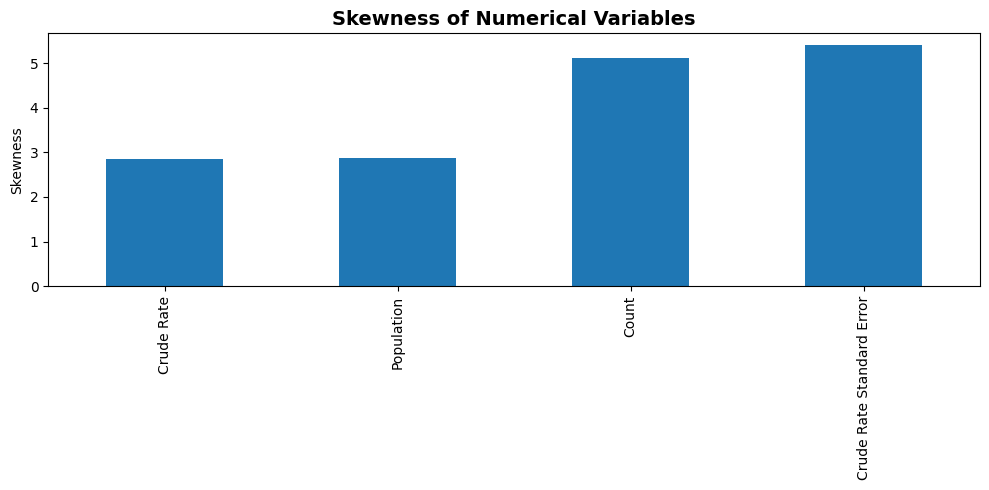

In [ ]:
plt.figure(figsize=(10,5))
skew_kurt['Skewness'].sort_values().plot(kind='bar')
plt.title('Skewness of Numerical Variables', fontsize=14, weight='bold')
plt.ylabel('Skewness')
plt.tight_layout()
plt.show()

# **Skewness Bar Chart**

All numerical variables have positive skewness greater than 2, indicating distributions with long right tails. Most observations are concentrated at lower values, while a relatively small number of observations have substantially higher values. The highest skewness is observed in Crude Rate Standard Error, followed by Count, suggesting these variables contain the greatest degree of asymmetry.

Count and Standard Error are much more skewed than Population and Crude Rate.
None of the variables are approximately normally distributed.

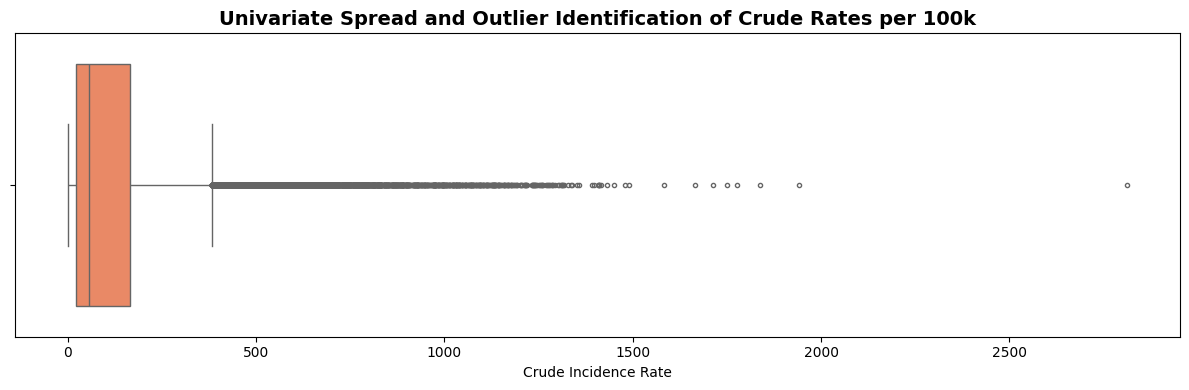

In [ ]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['Crude Rate'], color='coral', fliersize=3)
plt.title('Univariate Spread and Outlier Identification of Crude Rates per 100k', fontsize=14, weight='bold')
plt.xlabel('Crude Incidence Rate')
plt.tight_layout()
plt.show()

# **Crude Rate Box Plot**

1. Most crude rates lie in the lower range.
2. The median is close to the lower end of the data.
3. The right whisker is much longer than the left.
4. There are many observations beyond the upper whisker, extending up to approximately 2800 per 100,000.


*The boxplot confirms that the Crude Rate distribution is highly right-skewed and contains numerous high-value outliers. These observations are not necessarily data errors but likely represent regions or populations with unusually high disease incidence. Such extreme values contribute to the high skewness observed in the numerical summary.*

Text(0, 0.5, 'Frequency Density')

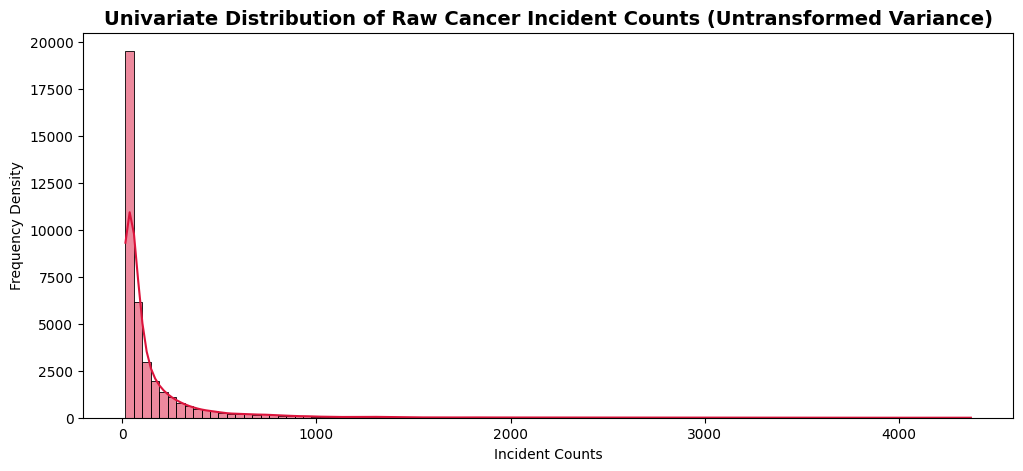

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Count'], bins=100, kde=True, color='crimson')
plt.title('Univariate Distribution of Raw Cancer Incident Counts (Untransformed Variance)', fontsize=14, weight='bold')
plt.xlabel('Incident Counts')
plt.ylabel('Frequency Density')

# **Incidence Histogram**

The histogram reveals a highly positively skewed distribution, with most observations clustered at lower incident counts and a long right tail representing a small number of regions with substantially higher counts.

The overlaid density curve confirms that the data deviate from normality. This visual finding is consistent with the calculated skewness (5.12) and kurtosis (37.04), indicating a highly asymmetric distribution with heavy tails and extreme observations.

Since these patterns are characteristic of epidemiological data and reflect meaningful population-level variation, the original distribution was retained without transformation.

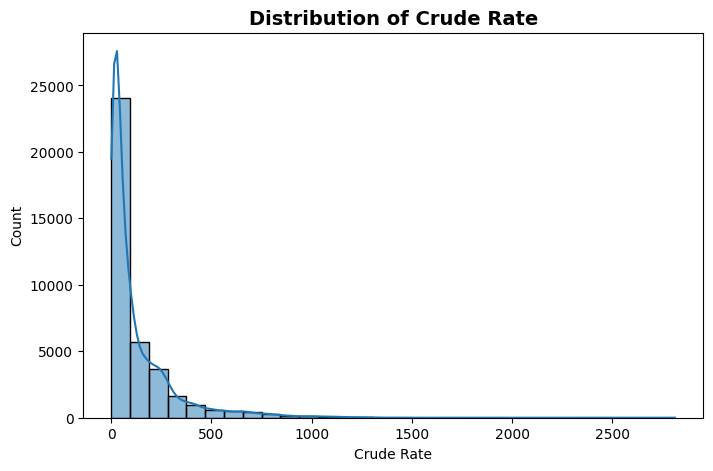

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Crude Rate'], bins=30, kde=True)
plt.title('Distribution of Crude Rate', fontsize=14, weight='bold')
plt.show()

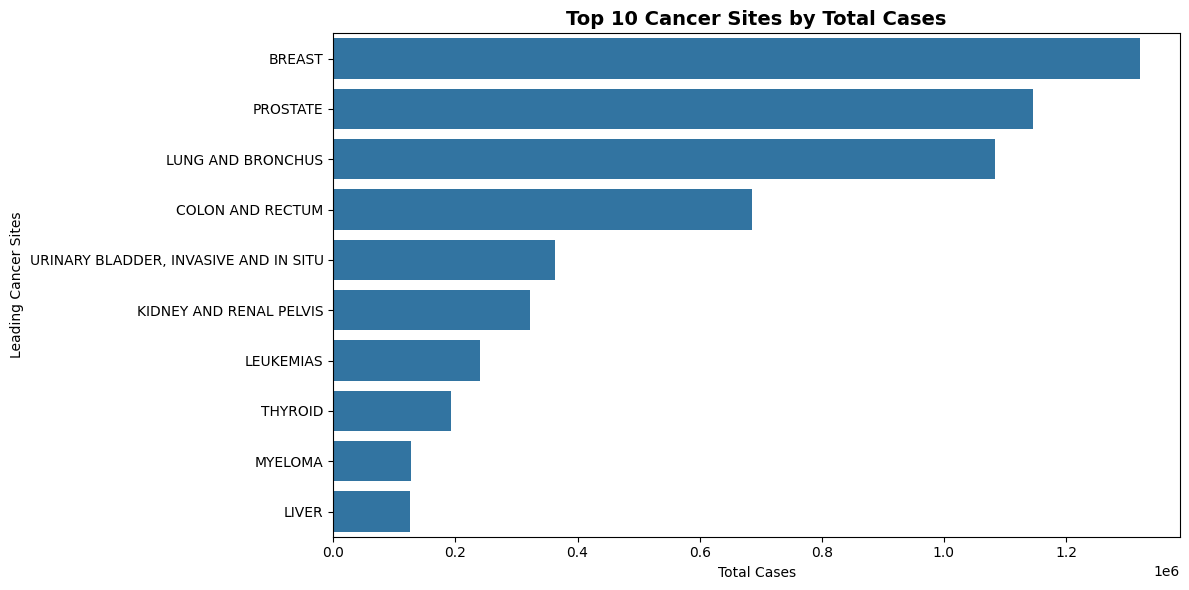

In [ ]:
top_cancers = (df.groupby('Leading Cancer Sites')['Count'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
sns.barplot(x=top_cancers.values, y=top_cancers.index)
plt.title('Top 10 Cancer Sites by Total Cases', fontsize=14, weight = 'bold')
plt.xlabel('Total Cases')
plt.tight_layout()
plt.show()

# **Top 10 Cancer Sites**

1. **Breast cancer** has the highest total number of reported cases (≈1.32 million), making it the most prevalent cancer site in the dataset.
2. **Prostate cance**r ranks second (≈1.15 million cases).
3. **Lung and Bronchus cancer** is the third most common, with over 1 million reported cases.
4. **Colon and Rectum cancer** ranks fourth, with a noticeable drop in total cases compared to the top three.
5. **Urinary Bladder and Kidney & Renal Pelvis** cancers have moderate case counts, ranging between approximately 300,000–360,000.
6. **Leukemias, Thyroid, Myeloma, and Liver** cancers have comparatively lower total case counts among the top 10.


*The distribution of total cases is uneven, with the top three cancer sites contributing substantially more cases than the remaining cancer types.*

*The chart suggests that Breast, Prostate, and Lung & Bronchus cancers represent the highest disease burden in the dataset and may warrant greater emphasis in healthcare planning and resource allocation.*

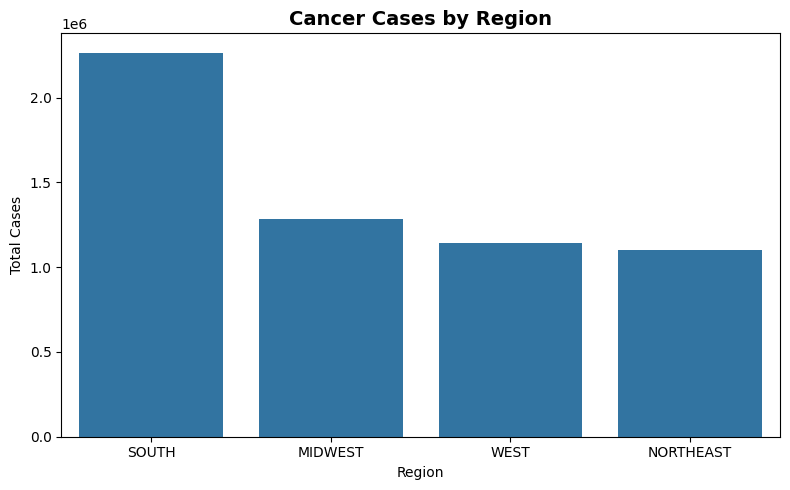

In [ ]:
region_cases = (df.groupby('Region')['Count'].sum().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=region_cases.index, y=region_cases.values)
plt.title('Cancer Cases by Region', fontsize=14, weight = 'bold')
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()

# **Cancer Cases by Region**

1. The South reports the highest number of cancer cases (approximately 2.3 million), indicating the greatest overall disease burden among all regions.
2. The Midwest rans second, with approximately 1.3 million reported cases.
3. The West and Northeast have comparable numbers of cases (around 1.1 million each).

*The South records nearly twice as many cases as the West and Northeast. Regional differences may be influenced by factors such as population size, age distribution, screening rates, healthcare access, and lifestyle or environmental risk factors.*

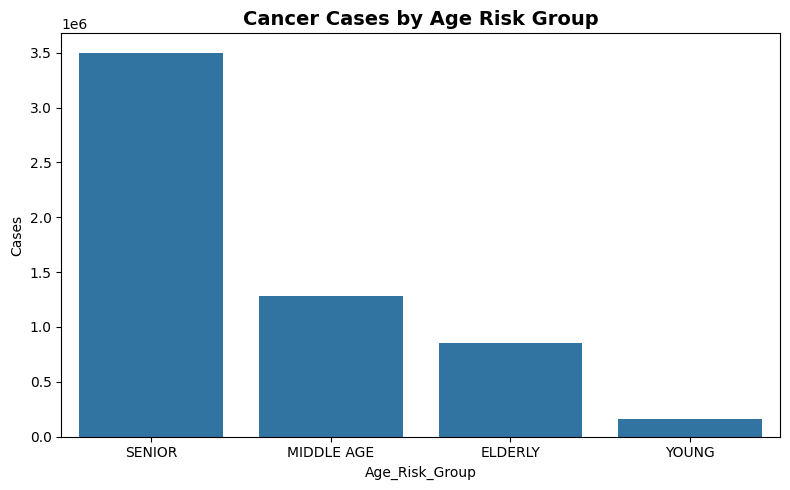

In [ ]:
age_cases = (df.groupby('Age_Risk_Group')['Count'].sum().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.barplot(x=age_cases.index, y=age_cases.values)
plt.title('Cancer Cases by Age Risk Group', fontsize=14, weight = 'bold')
plt.ylabel('Cases')
plt.tight_layout()
plt.show()

# **Cancer by Age Risk Group**

1. The Senior age group accounts for the highest number of cancer cases (approximately 3.5 million).
2. The Middle Age group ranks second, with around 1.3 million cases.
3. The Elderly group reports approximately 850,000 cases.
4. The Young age group has the fewest reported cancer cases (less than 200,000).


*The results indicate that cancer incidence increases with age, with older populations experiencing a substantially greater disease burden.*

*These findings are consistent with established epidemiological evidence that age is a major risk factor for cancer development.*

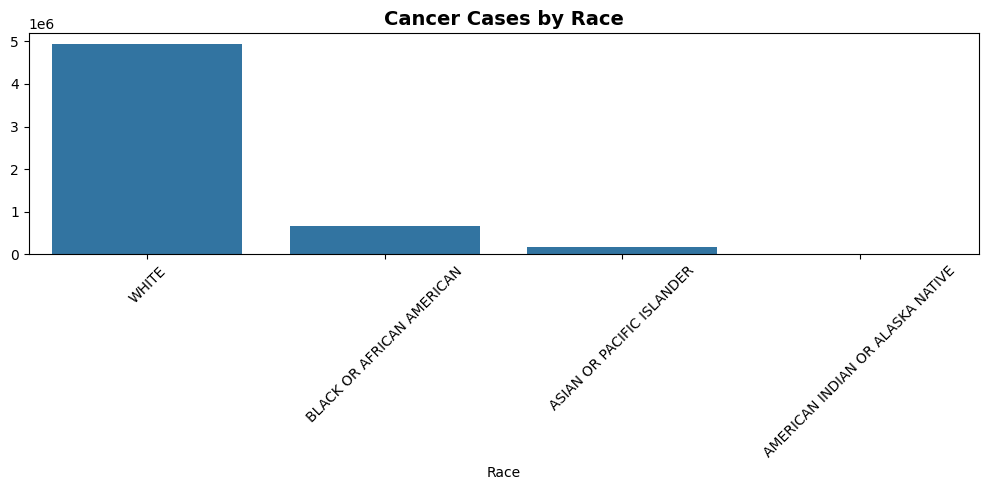

In [ ]:
race_cases = (df.groupby('Race')['Count'].sum().sort_values(ascending=False))
plt.figure(figsize=(10,5))
sns.barplot(x=race_cases.index, y=race_cases.values)
plt.xticks(rotation=45)
plt.title('Cancer Cases by Race', fontsize=14, weight = 'bold')
plt.tight_layout()
plt.show()

# **Cancer Cases by Race**

1. The White population reports the highest number of cancer cases (approximately 4.9 million), accounting for the largest disease burden in the dataset.
2. The Black or African American population ranks second, with approximately 650,000 cases.
3. The Asian or Pacific Islander population reports considerably fewer cases (around 180,000).
4. The American Indian or Alaska Native population has the lowest reported number of cancer cases.


*The substantial differences in total cases across racial groups may reflect differences in population size, age distribution, cancer prevalence, healthcare access, and screening practices, rather than race alone.*

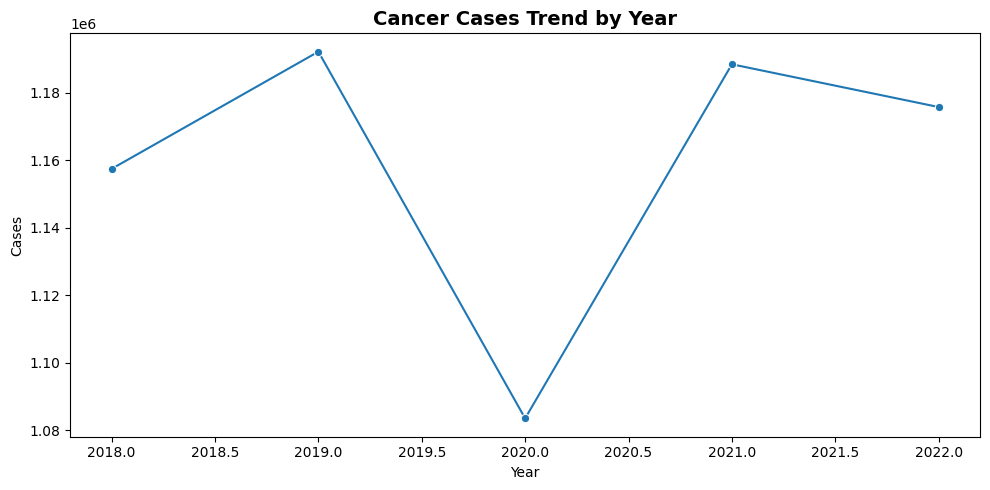

In [ ]:
yearly_cases = (df.groupby('Year')['Count'].sum())
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_cases.index, y=yearly_cases.values, marker='o')
plt.title('Cancer Cases Trend by Year', fontsize=14, weight = 'bold')
plt.ylabel('Cases')
plt.tight_layout()
plt.show()

# **Cancer Case Trend by Year**

1. Cancer cases increased from 2018 to 2019.
2. A noticeable decline in reported cases is observed in 2020.
Cases rebounded sharply in 2021, reaching levels comparable to or slightly below the 2019 peak.
3. A slight decrease is observed in 2022, although case counts remain higher than in 2018.


*Overall, the trend indicates minor year-to-year fluctuations rather than a consistent upward or downward pattern.*

*The dip in 2020 may be associated with disruptions in healthcare services, cancer screening, and diagnosis during the COVID-19 pandemic, rather than an actual reduction in cancer occurrence. (Mention this only if your discussion allows contextual interpretation.)*

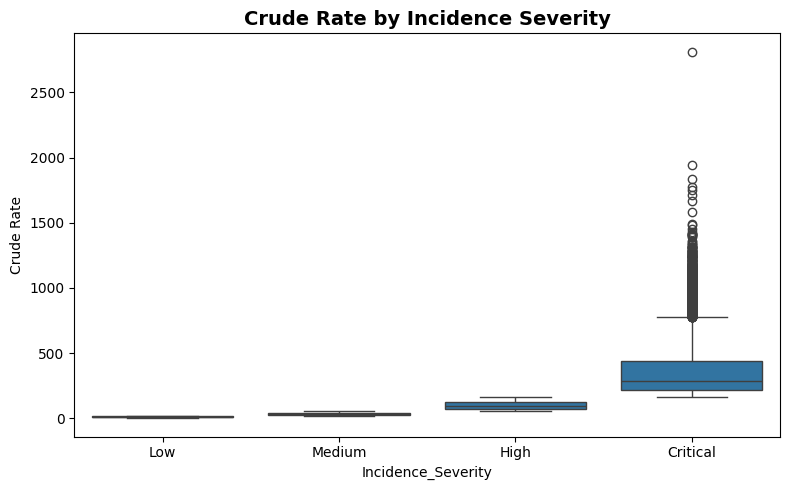

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Incidence_Severity', y='Crude Rate')
plt.title('Crude Rate by Incidence Severity', fontsize=14, weight = 'bold')
plt.tight_layout()
plt.show()

# **Crude Rate by Incidence Severity**

1. The median crude rate increases progressively from Low → Medium → High → Critical severity levels.
2. Critical incidence severity exhibits the highest crude rates among all groups.
3. The Critical category shows the widest spread (largest IQR), indicating greater variability in crude rates.
4. A large number of high-value outliers are observed in the Critical category, with some crude rates exceeding 2,800 per 100,000.
5. Low, Medium, and High severity groups have relatively smaller variability and fewer extreme values.

*The results suggest a positive association between incidence severity and crude rate, where higher severity levels correspond to higher and more variable crude rates.*

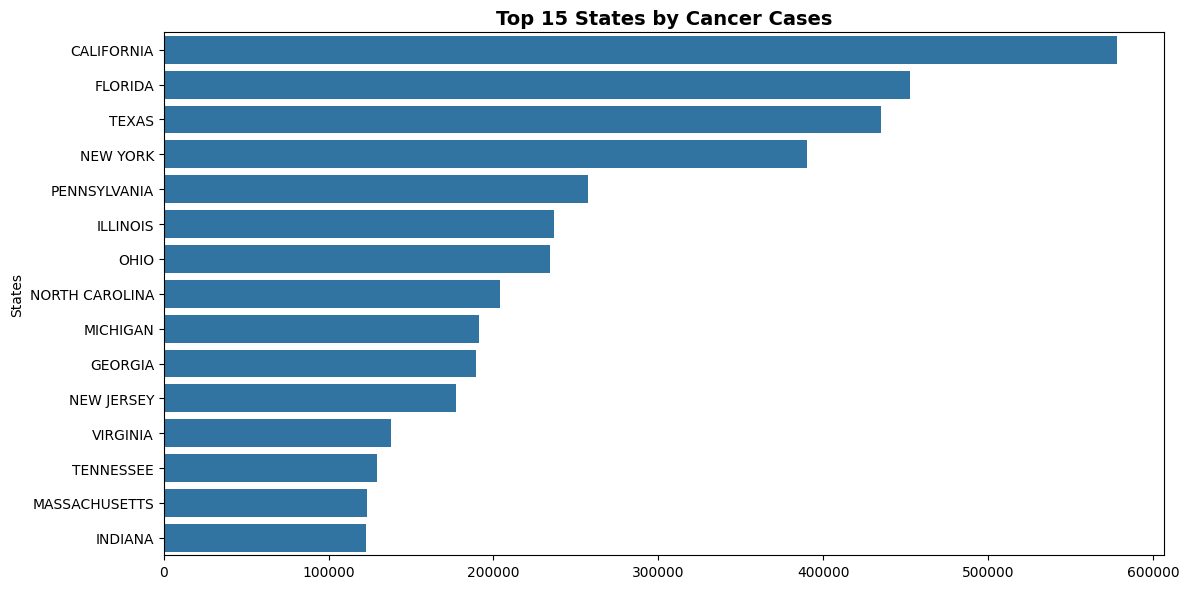

In [ ]:
state_cases = (df.groupby('States')['Count'].sum().sort_values(ascending=False).head(15))
plt.figure(figsize=(12,6))
sns.barplot(x=state_cases.values, y=state_cases.index)
plt.title('Top 15 States by Cancer Cases', fontsize=14, weight = 'bold')
plt.tight_layout()
plt.show()

# **Top 15 States by Cancer Cases**

1. **California** reports the highest number of cancer cases (approximately 580,000), ranking first among all states.
2. **Florida and Texas** rank second and third, respectively.
3. **New York** ranks fourth, followed by Pennsylvania.
4. **Illinois and Ohio** have similar total case counts, both exceeding 230,000 cases.
5. The remaining states (North Carolina, Michigan, Georgia, New Jersey, Virginia, Tennessee, Massachusetts, and Indiana) report comparatively lower case counts.

*The distribution indicates that a small number of highly populated states contribute a disproportionately large share of total cancer cases.*

*Differences in total cases are likely influenced by population size, demographic composition, healthcare access, and cancer screening practices, rather than geographic location alone.*

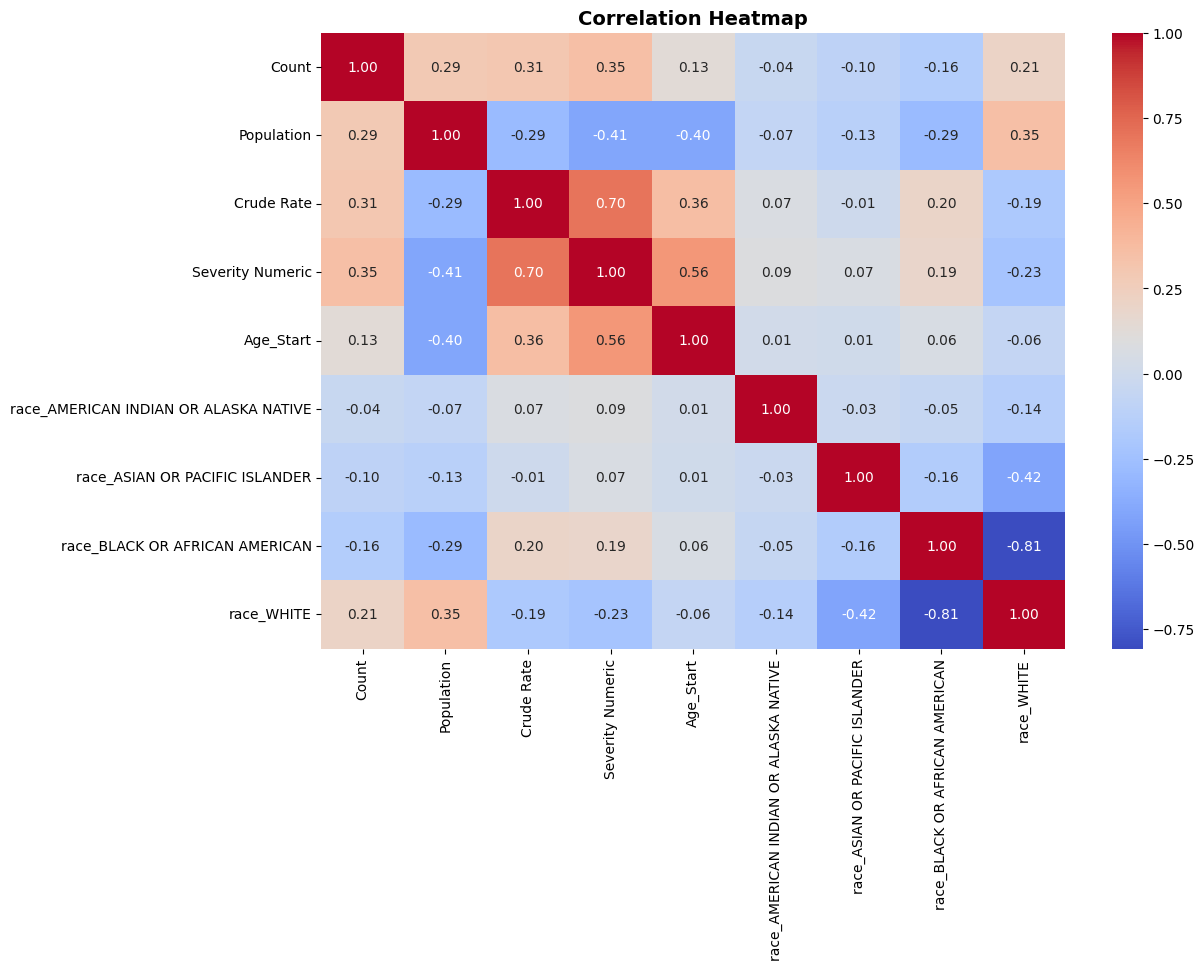

In [ ]:
corr_cols = ['Count', 'Population', 'Crude Rate', 'Severity Numeric', 'Age_Start',
             'race_AMERICAN INDIAN OR ALASKA NATIVE','race_ASIAN OR PACIFIC ISLANDER', 'race_BLACK OR AFRICAN AMERICAN', 'race_WHITE']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap', fontsize=14, weight = 'bold')
plt.show()

# **Correlation Heatmap**

1. Crude Rate and Severity Numeric show a strong positive correlation (r = 0.70), indicating that higher incidence severity is associated with higher crude rates.
2. Severity Numeric and Age_Start have a moderate positive correlation (r = 0.56), suggesting that higher severity tends to occur in older age groups.
3. Count has weak positive correlations with:

      Severity Numeric (r = 0.35)

      Crude Rate (r = 0.31)

      Population (r = 0.29)

4. Population has a moderate negative correlation with:

      Severity Numeric (r = -0.41)

      Age_Start (r = -0.40)

      Crude Rate (r = -0.29)

5. The race dummy variables exhibit weak correlations with most numerical variables, indicating no strong linear relationship.
6. The strong negative correlation between some race dummy variables (e.g., Black or African American and White, r = -0.81) is expected because these are one-hot encoded categorical variables. Membership in one race category excludes membership in another, making such negative correlations a consequence of the encoding rather than a meaningful epidemiological relationship.


*Overall, no severe multicollinearity is observed among the main numerical variables, except for the expected relationships involving the encoded race categories.*

In [ ]:
pivot_table = pd.pivot_table(df, values='Crude Rate', index='Region', columns='Age_Risk_Group', aggfunc='mean')
pivot_table

Age_Risk_Group,ELDERLY,MIDDLE AGE,SENIOR,YOUNG
Region,,,,
MIDWEST,195.455318,59.955319,185.129613,11.778026
NORTHEAST,202.591436,57.105192,167.944842,12.770827
SOUTH,201.527421,60.312991,179.264776,12.403618
WEST,185.321198,52.058915,157.193039,11.093064


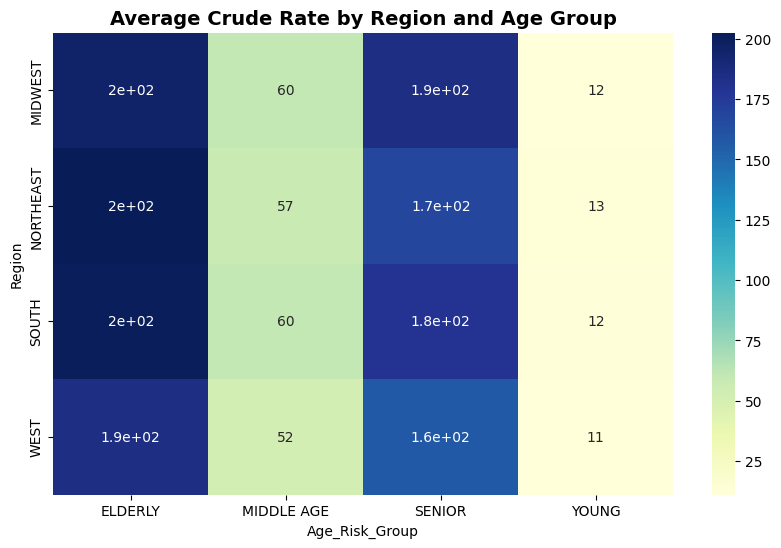

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title('Average Crude Rate by Region and Age Group', fontsize=14, weight = 'bold')
plt.show()

# **Average Crude Rate by Region and Age Group**
1. Across all regions, the Elderly age group has the highest average crude rate (approximately 185–203 per 100,000).
2. The Senior group records the second-highest crude rates, ranging from approximately 157–185 per 100,000.
3. The Middle Age group has moderate crude rates (approximately 52–60 per 100,000).
4. The Young age group consistently has the lowest crude rates across all regions (approximately 11–13 per 100,000).
5. The Northeast has the highest average crude rate among the Elderly group (≈202.6 per 100,000).
6. The Midwest records the highest average crude rate for the Senior group (≈185.1 per 100,000).
7. The West generally reports the lowest average crude rates across most age groups.
8. The heatmap highlights a clear pattern that average crude rates increase with age, regardless of region.
9. Regional differences exist but are relatively modest compared to the effect of age, suggesting that age is a stronger determinant of crude cancer incidence than geographic region in this dataset.

# **Overall Key Insights**


---



1. The dataset is **highly right-skewed** with several extreme values, which is
typical of healthcare data and reflects genuine variation in cancer incidence.
2. **Breast, Prostate, and Lung & Bronchus cancers** contribute the **highest number of cases**, indicating the greatest disease burden.
3. Cancer **incidence increases with age**, with the Senior and Elderly groups experiencing the highest case counts and crude incidence rates.
4. The **South** and highly populated states (California, Florida, Texas, and New York) account for the largest number of cancer cases, suggesting areas that require greater healthcare resources.
5. Critical incidence severity is associated with the highest crude rates and the greatest variability, emphasizing the importance of early diagnosis and timely treatment.
6. A strong **positive correlation exists between crude rate and incidence severity** (r = 0.70), indicating that higher severity is linked to increased cancer incidence.
7. Cancer cases fluctuate slightly across years, with a noticeable decline in 2020 followed by recovery, suggesting the influence of external factors such as healthcare disruptions.
8. Overall, cancer burden varies significantly across cancer sites, age groups, regions, and states, highlighting the need for targeted public health interventions rather than a one-size-fits-all approach.

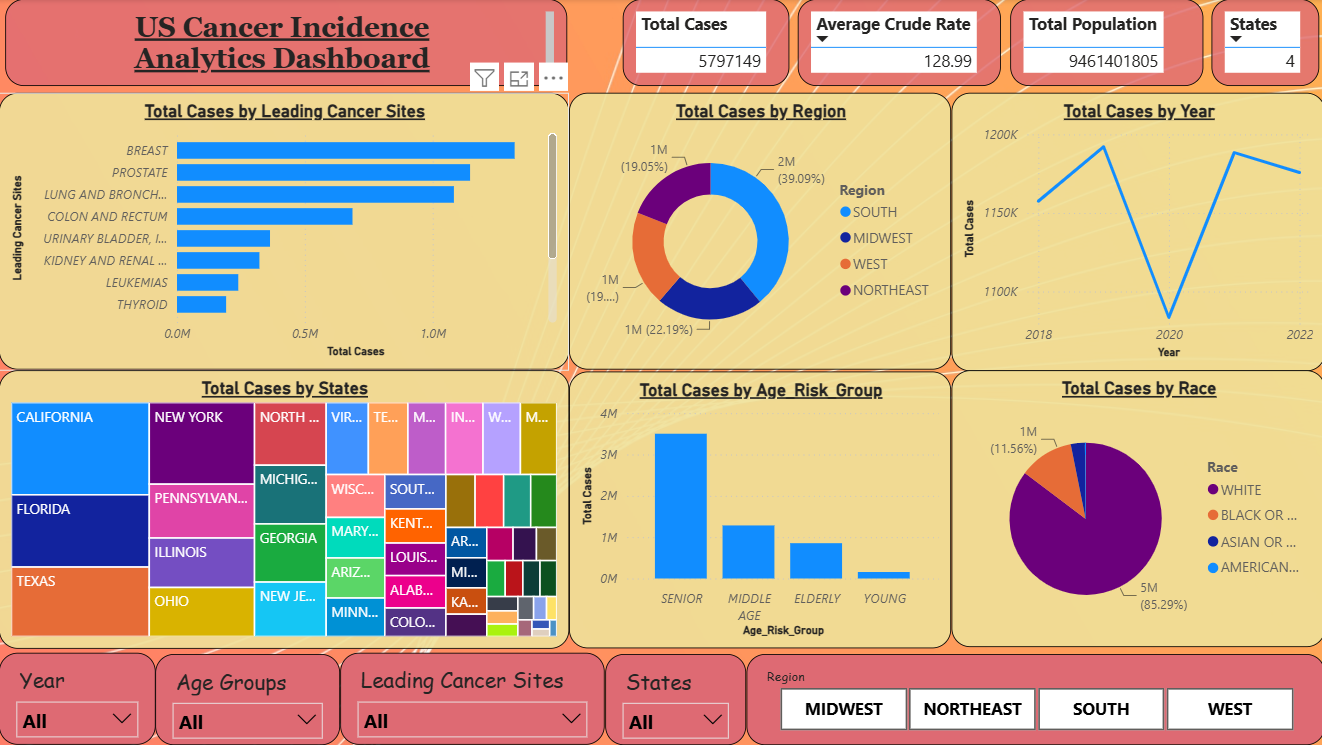

# **Conclusion & Recommendations**


---


1. **Prioritize screening for high-burden cancers.**

Breast, Prostate, and Lung & Bronchus cancers account for the highest number of cases.

*Recommendation: Increase awareness campaigns, routine screening, and early detection programs targeting these cancers.*

2. **Focus healthcare resources on older adults.**

Seniors and Elderly populations exhibit the highest cancer burden and crude incidence rates.

*Recommendation: Expand age-specific screening programs, preventive care, and regular health check-ups for individuals aged 50 years and above.*

3. **Strengthen cancer control efforts in high-burden regions.**

The South reports the highest total cancer cases, while regional crude rates vary across age groups.

*Recommendation: Allocate additional healthcare funding, screening facilities, and oncology services to high-burden regions.*

4. **Improve healthcare planning in highly populated states.**

California, Florida, Texas, and New York report the greatest number of cancer cases.

*Recommendation: Increase healthcare infrastructure, specialist availability, and screening capacity in these states to manage the larger patient load.*

5. **Prioritize patients with high incidence severity.**

Critical severity cases have the highest crude rates and greatest variability.

*Recommendation: Implement early detection strategies to reduce progression to critical stages and improve treatment outcomes.*

6. **Promote early diagnosis.**

The strong positive correlation between crude rate and severity indicates that more severe disease is associated with higher incidence rates.

*Recommendation: Encourage regular cancer screening and timely diagnosis to identify cancers before they progress to advanced stages.*

7. **Maintain surveillance across demographic groups.**

Cancer burden differs across races, age groups, and regions.

*Recommendation: Develop targeted public health interventions while considering demographic differences in population size, healthcare access, and risk factors.*

8. **Prepare healthcare systems for fluctuating cancer burden.**

Annual cancer cases fluctuate, with a noticeable decline during 2020 followed by recovery.

*Recommendation: Ensure continuity of cancer screening and treatment services during public health emergencies to minimize delayed diagnoses.*

9. **Use data-driven resource allocation.**

The presence of highly skewed distributions and extreme values indicates that some regions experience substantially higher disease burden.

*Recommendation: Allocate resources based on disease burden rather than distributing them uniformly across all regions.*

10. **Support continuous cancer surveillance.**

Significant variation exists across cancer sites, regions, age groups, and states.

*Recommendation: Continuously monitor cancer trends to support evidence-based policymaking and optimize preventive healthcare strategies.*